In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [18]:
import os

# اطبع كل اللي في kaggle/input
print(os.listdir('/kaggle/input/'))

['datasets']


In [19]:
import os

# شوف جوّا datasets
print(os.listdir('/kaggle/input/datasets'))

['gunavenkatdoddi']


In [20]:
import os

print(os.listdir('/kaggle/input/datasets/gunavenkatdoddi'))

['eye-diseases-classification']


In [23]:
import os

# المسار الكامل الصح
base_path = '/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset'

print(os.listdir(base_path))

['glaucoma', 'normal', 'diabetic_retinopathy', 'cataract']


**Dataset + Basic Preprocessing**

📁 Dataset structure:
dataset/
  glaucoma/
    → 1007 images
  normal/
    → 1074 images
  diabetic_retinopathy/
    → 1098 images
  cataract/
    → 1038 images
  cataract: 1038 images
  diabetic_retinopathy: 1098 images
  glaucoma: 1007 images
  normal: 1074 images

✅ Total classes: 4
✅ Total images: 4217


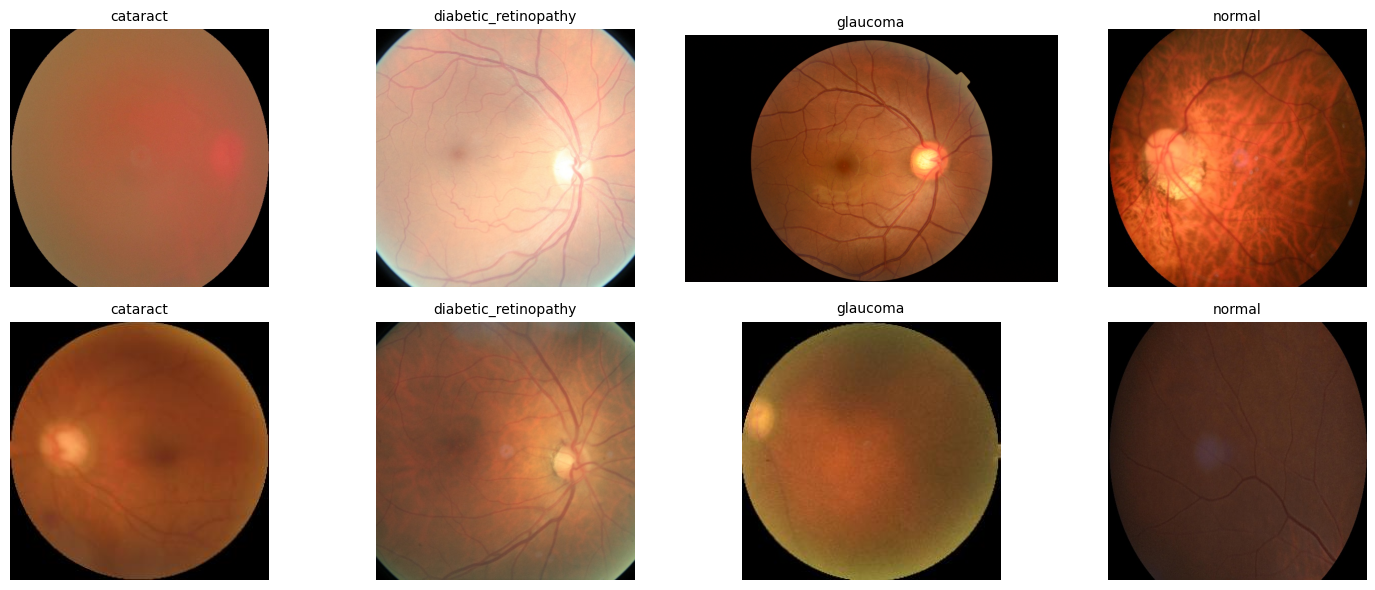


🧹 Checking for corrupt images...
  Found 0 corrupt images
  cataract: train=726, val=155, test=157
  diabetic_retinopathy: train=768, val=164, test=166
  glaucoma: train=704, val=151, test=152
  normal: train=751, val=161, test=162

📐 Resizing images to (224, 224)...
✅ Resized 4217 images
✅ Dataset saved to: /kaggle/working/eye_dataset
📁 Dataset structure:
dataset/
  glaucoma/
    → 1007 images
  normal/
    → 1074 images
  diabetic_retinopathy/
    → 1098 images
  cataract/
    → 1038 images
  cataract: 1038 images
  diabetic_retinopathy: 1098 images
  glaucoma: 1007 images
  normal: 1074 images

✅ Total classes: 4
✅ Total images: 4217


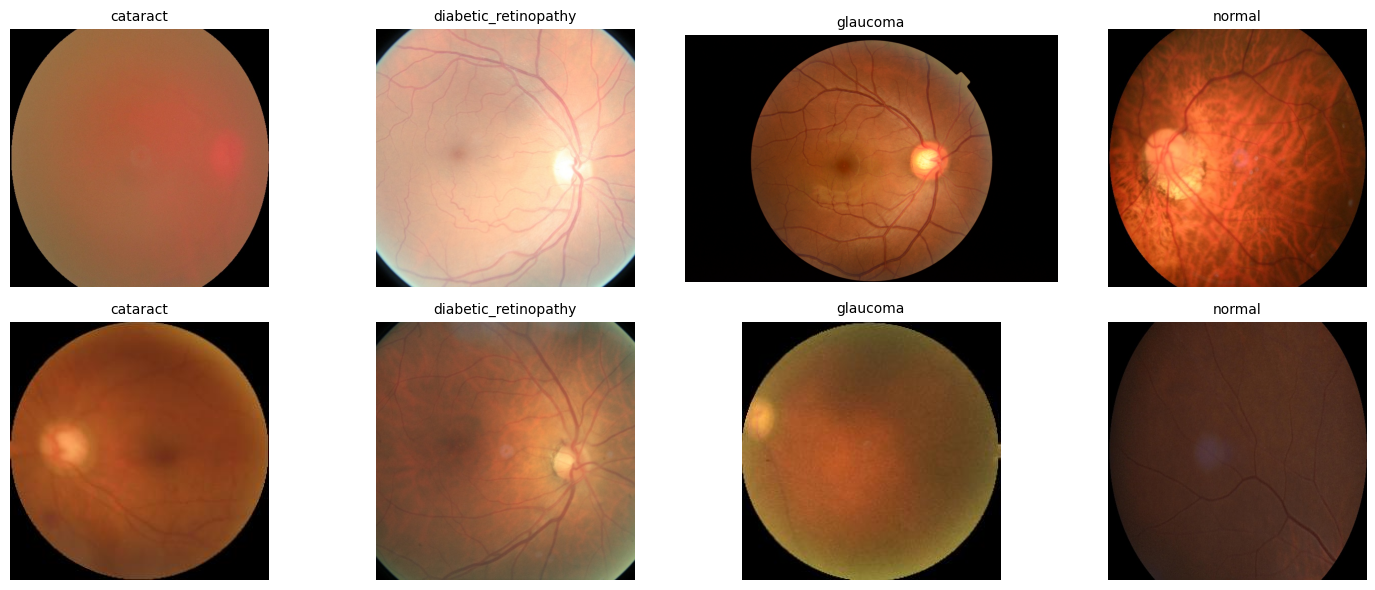


🧹 Checking for corrupt images...
  Found 0 corrupt images
  cataract: train=726, val=155, test=157
  diabetic_retinopathy: train=768, val=164, test=166
  glaucoma: train=704, val=151, test=152
  normal: train=751, val=161, test=162

📐 Resizing images to (224, 224)...
✅ Resized 4217 images
✅ Dataset saved to: /kaggle/working/eye_dataset


In [27]:
# ============================================================
# PERSON 1: Dataset + Basic Preprocessing
# ============================================================
import os
import shutil
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# ── 1. Explore the dataset ──────────────────────────────────
DATASET_PATH = "/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset"

print("📁 Dataset structure:")
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 1:
        print(f'{indent}  → {len(files)} images')

# ── 2. Count images per class ───────────────────────────────
classes = sorted(os.listdir(DATASET_PATH))
class_counts = {}
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[cls] = count
        print(f"  {cls}: {count} images")

print(f"\n✅ Total classes: {len(class_counts)}")
print(f"✅ Total images: {sum(class_counts.values())}")

# ── 3. Visualize sample images ──────────────────────────────
fig, axes = plt.subplots(2, len(class_counts), figsize=(15, 6))
for i, (cls, _) in enumerate(class_counts.items()):
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for j in range(2):
        img = Image.open(os.path.join(cls_path, random.choice(images)))
        axes[j, i].imshow(img)
        axes[j, i].set_title(cls, fontsize=10)
        axes[j, i].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=100)
plt.show()

# ── 4. Clean images (remove corrupt) ───────────────────────
print("\n🧹 Checking for corrupt images...")
corrupt = []
for cls in class_counts:
    cls_path = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except Exception:
            corrupt.append(img_path)
            print(f"  ❌ Corrupt: {img_path}")

print(f"  Found {len(corrupt)} corrupt images")

# ── 5. Split dataset → Train / Val / Test ───────────────────
OUTPUT_DIR = '/kaggle/working/eye_dataset'
SPLITS = {'train': 0.7, 'val': 0.15, 'test': 0.15}
random.seed(42)

for split in SPLITS:
    for cls in class_counts:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

for cls in class_counts:
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)
    
    n = len(images)
    n_train = int(n * SPLITS['train'])
    n_val   = int(n * SPLITS['val'])
    
    splits_imgs = {
        'train': images[:n_train],
        'val':   images[n_train:n_train + n_val],
        'test':  images[n_train + n_val:]
    }
    
    for split, split_imgs in splits_imgs.items():
        for img_name in split_imgs:
            src = os.path.join(cls_path, img_name)
            dst = os.path.join(OUTPUT_DIR, split, cls, img_name)
            shutil.copy2(src, dst)
    
    print(f"  {cls}: train={len(splits_imgs['train'])}, "
          f"val={len(splits_imgs['val'])}, test={len(splits_imgs['test'])}")

# ── 6. Resize images ────────────────────────────────────────
TARGET_SIZE = (224, 224)
print(f"\n📐 Resizing images to {TARGET_SIZE}...")

from PIL import Image as PILImage
resized_count = 0
for split in SPLITS:
    for cls in class_counts:
        dir_path = os.path.join(OUTPUT_DIR, split, cls)
        for img_name in os.listdir(dir_path):
            img_path = os.path.join(dir_path, img_name)
            try:
                img = PILImage.open(img_path).convert('RGB')
                img = img.resize(TARGET_SIZE, PILImage.LANCZOS)
                img.save(img_path)
                resized_count += 1
            except Exception as e:
                print(f"  Warning: {img_name} → {e}")

print(f"✅ Resized {resized_count} images")
print(f"✅ Dataset saved to: {OUTPUT_DIR}")# ============================================================
# PERSON 1: Dataset + Basic Preprocessing
# ============================================================
import os
import shutil
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# ── 1. Explore the dataset ──────────────────────────────────
DATASET_PATH = "/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset"

print("📁 Dataset structure:")
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 1:
        print(f'{indent}  → {len(files)} images')

# ── 2. Count images per class ───────────────────────────────
classes = sorted(os.listdir(DATASET_PATH))
class_counts = {}
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[cls] = count
        print(f"  {cls}: {count} images")

print(f"\n✅ Total classes: {len(class_counts)}")
print(f"✅ Total images: {sum(class_counts.values())}")

# ── 3. Visualize sample images ──────────────────────────────
fig, axes = plt.subplots(2, len(class_counts), figsize=(15, 6))
for i, (cls, _) in enumerate(class_counts.items()):
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for j in range(2):
        img = Image.open(os.path.join(cls_path, random.choice(images)))
        axes[j, i].imshow(img)
        axes[j, i].set_title(cls, fontsize=10)
        axes[j, i].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=100)
plt.show()

# ── 4. Clean images (remove corrupt) ───────────────────────
print("\n🧹 Checking for corrupt images...")
corrupt = []
for cls in class_counts:
    cls_path = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except Exception:
            corrupt.append(img_path)
            print(f"  ❌ Corrupt: {img_path}")

print(f"  Found {len(corrupt)} corrupt images")

# ── 5. Split dataset → Train / Val / Test ───────────────────
OUTPUT_DIR = '/kaggle/working/eye_dataset'
SPLITS = {'train': 0.7, 'val': 0.15, 'test': 0.15}
random.seed(42)

for split in SPLITS:
    for cls in class_counts:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

for cls in class_counts:
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)
    
    n = len(images)
    n_train = int(n * SPLITS['train'])
    n_val   = int(n * SPLITS['val'])
    
    splits_imgs = {
        'train': images[:n_train],
        'val':   images[n_train:n_train + n_val],
        'test':  images[n_train + n_val:]
    }
    
    for split, split_imgs in splits_imgs.items():
        for img_name in split_imgs:
            src = os.path.join(cls_path, img_name)
            dst = os.path.join(OUTPUT_DIR, split, cls, img_name)
            shutil.copy2(src, dst)
    
    print(f"  {cls}: train={len(splits_imgs['train'])}, "
          f"val={len(splits_imgs['val'])}, test={len(splits_imgs['test'])}")

# ── 6. Resize images ────────────────────────────────────────
TARGET_SIZE = (224, 224)
print(f"\n📐 Resizing images to {TARGET_SIZE}...")

from PIL import Image as PILImage
resized_count = 0
for split in SPLITS:
    for cls in class_counts:
        dir_path = os.path.join(OUTPUT_DIR, split, cls)
        for img_name in os.listdir(dir_path):
            img_path = os.path.join(dir_path, img_name)
            try:
                img = PILImage.open(img_path).convert('RGB')
                img = img.resize(TARGET_SIZE, PILImage.LANCZOS)
                img.save(img_path)
                resized_count += 1
            except Exception as e:
                print(f"  Warning: {img_name} → {e}")

print(f"✅ Resized {resized_count} images")
print(f"✅ Dataset saved to: {OUTPUT_DIR}")

**Preprocessing + DataLoader**

📊 Dataset sizes:
  Train : 2949
  Val   : 631
  Test  : 637

🏷️  Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

✅ Batch shape: torch.Size([32, 3, 224, 224])
✅ Labels: [2, 0, 1, 0, 3, 1, 0, 0]


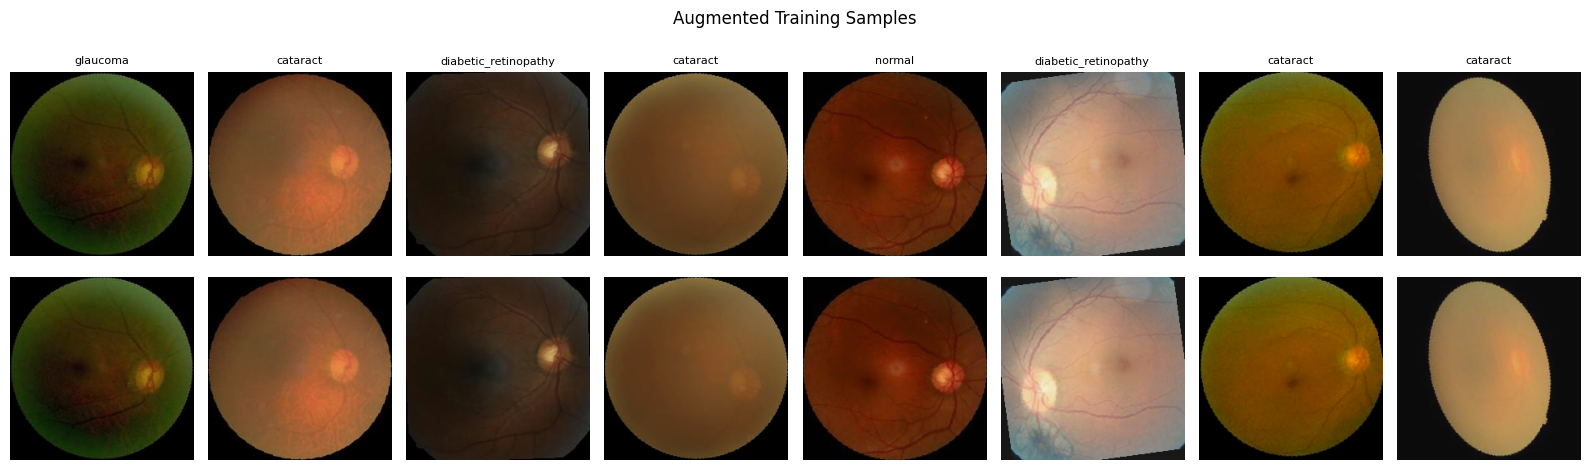


✅ DataLoaders ready!
✅ Loader info saved to /kaggle/working/loader_info.pkl


In [30]:
# ============================================================
# PERSON 2: Preprocessing + DataLoader
# ============================================================
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = '/kaggle/working/eye_dataset'
BATCH_SIZE = 32
IMG_SIZE = 224

# ── 1. Define transforms with augmentation ──────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ── 2. Load datasets ─────────────────────────────────────────
train_dataset = datasets.ImageFolder(root=f'{DATA_DIR}/train',
                                     transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=f'{DATA_DIR}/val',
                                     transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(root=f'{DATA_DIR}/test',
                                     transform=val_test_transforms)

print("📊 Dataset sizes:")
print(f"  Train : {len(train_dataset)}")
print(f"  Val   : {len(val_dataset)}")
print(f"  Test  : {len(test_dataset)}")
print(f"\n🏷️  Classes: {train_dataset.classes}")

# ── 3. Create DataLoaders ────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

# ── 4. Verify a batch ────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"\n✅ Batch shape: {images.shape}")   # [32, 3, 224, 224]
print(f"✅ Labels: {labels[:8].tolist()}")

# ── 5. Visualize augmented samples ──────────────────────────
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i in range(8):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    axes[0, i].imshow(img)
    axes[0, i].set_title(train_dataset.classes[labels[i]], fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
plt.suptitle('Augmented Training Samples', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/augmented_samples.png', dpi=100)
plt.show()

# ── 6. Save loader info for next persons ────────────────────
import pickle
loader_info = {
    'classes': train_dataset.classes,
    'num_classes': len(train_dataset.classes),
    'train_size': len(train_dataset),
    'val_size': len(val_dataset),
    'test_size': len(test_dataset),
    'batch_size': BATCH_SIZE,
    'img_size': IMG_SIZE
}
with open('/kaggle/working/loader_info.pkl', 'wb') as f:
    pickle.dump(loader_info, f)

print("\n✅ DataLoaders ready!")
print(f"✅ Loader info saved to /kaggle/working/loader_info.pkl")

**Model Building**

In [31]:
# ============================================================
# PERSON 3: Model Building
# ============================================================
import torch
import torch.nn as nn
from torchvision import models
import pickle

# ── Load info ────────────────────────────────────────────────
with open('/kaggle/working/loader_info.pkl', 'rb') as f:
    info = pickle.load(f)
NUM_CLASSES = info['num_classes']
print(f"🏷️  Number of classes: {NUM_CLASSES} → {info['classes']}")

# ── Option A: Simple CNN from scratch ───────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),                                    # 112x112
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),                                    # 56x56
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),                                    # 28x28
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2),                                    # 14x14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))

# ── Option B: Pretrained ResNet18 (recommended ✅) ───────────
class EyeDiseaseModel(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet18(weights=weights)
        
        # Freeze early layers for transfer learning
        for name, param in self.backbone.named_parameters():
            if 'layer4' not in name and 'fc' not in name:
                param.requires_grad = False
        
        # Replace final layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

# ── Build model ──────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n💻 Device: {device}")

USE_PRETRAINED = True   # ← change to False for SimpleCNN

if USE_PRETRAINED:
    model = EyeDiseaseModel(num_classes=NUM_CLASSES, pretrained=True)
    print("✅ Using pretrained ResNet18 with transfer learning")
else:
    model = SimpleCNN(num_classes=NUM_CLASSES)
    print("✅ Using SimpleCNN from scratch")

model = model.to(device)

# ── Loss + Optimizer ─────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# ── Model summary ────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Total params    : {total_params:,}")
print(f"📊 Trainable params: {trainable_params:,}")

# ── Quick forward pass test ──────────────────────────────────
dummy = torch.randn(4, 3, 224, 224).to(device)
out = model(dummy)
print(f"✅ Forward pass OK → output shape: {out.shape}")

# ── Save model + components ──────────────────────────────────
torch.save({
    'model_state': model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'scheduler_state': scheduler.state_dict(),
    'num_classes': NUM_CLASSES,
    'classes': info['classes'],
    'use_pretrained': USE_PRETRAINED
}, '/kaggle/working/model_checkpoint.pth')

print("\n✅ Model saved to /kaggle/working/model_checkpoint.pth")

🏷️  Number of classes: 4 → ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

💻 Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


✅ Using pretrained ResNet18 with transfer learning

📊 Total params    : 11,308,868
📊 Trainable params: 8,526,084
✅ Forward pass OK → output shape: torch.Size([4, 4])

✅ Model saved to /kaggle/working/model_checkpoint.pth


**Training & Evaluation**

⚠️ Optimizer state mismatch - سيبدأ من أول
🚀 Training on cuda for 15 epochs...

Epoch 01/15 | Train Loss: 0.6068 Acc: 0.7694 | Val Loss: 0.3785 Acc: 0.8605 ✅ saved
Epoch 02/15 | Train Loss: 0.3928 Acc: 0.8566 | Val Loss: 0.6144 Acc: 0.7924
Epoch 03/15 | Train Loss: 0.5129 Acc: 0.7935 | Val Loss: 0.4229 Acc: 0.8368
Epoch 04/15 | Train Loss: 0.3699 Acc: 0.8688 | Val Loss: 0.3558 Acc: 0.8637 ✅ saved
Epoch 05/15 | Train Loss: 0.3304 Acc: 0.8901 | Val Loss: 0.3395 Acc: 0.8700 ✅ saved
Epoch 06/15 | Train Loss: 0.2800 Acc: 0.9051 | Val Loss: 0.2670 Acc: 0.9033 ✅ saved
Epoch 07/15 | Train Loss: 0.2318 Acc: 0.9173 | Val Loss: 0.2706 Acc: 0.9097 ✅ saved
Epoch 08/15 | Train Loss: 0.2410 Acc: 0.9200 | Val Loss: 0.3272 Acc: 0.8954
Epoch 09/15 | Train Loss: 0.2790 Acc: 0.9061 | Val Loss: 0.4039 Acc: 0.8796
Epoch 10/15 | Train Loss: 0.2118 Acc: 0.9247 | Val Loss: 0.2431 Acc: 0.9113 ✅ saved
Epoch 11/15 | Train Loss: 0.1630 Acc: 0.9434 | Val Loss: 0.2234 Acc: 0.9350 ✅ saved
Epoch 12/15 | Train Loss: 0.

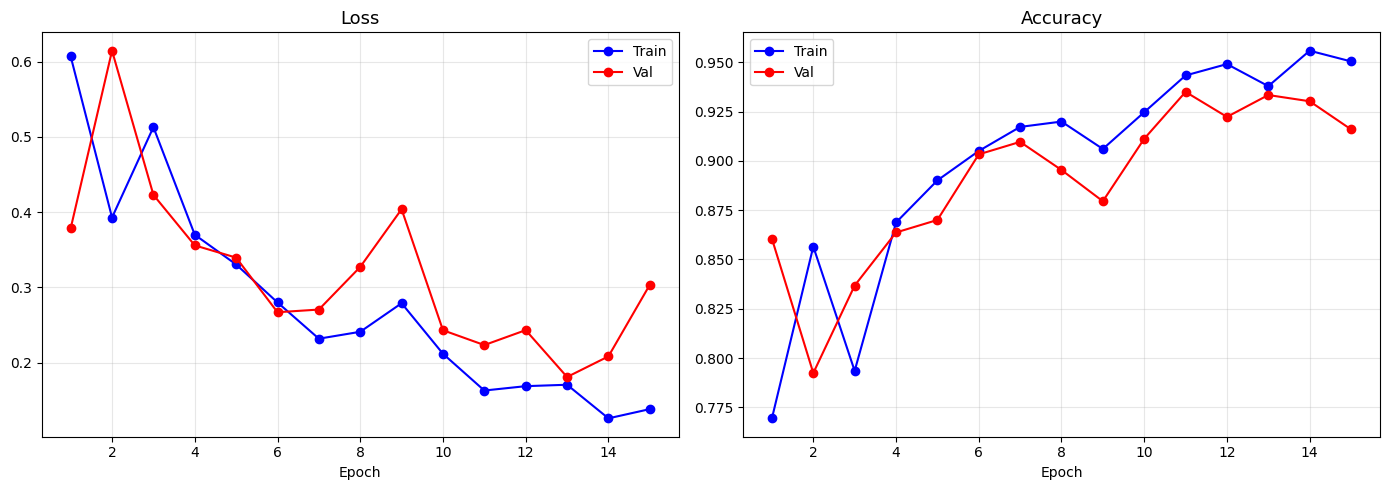


🎯 Test Accuracy: 0.9231 (92.31%)

📊 Classification Report:
                      precision    recall  f1-score   support

            cataract       0.91      0.94      0.92       157
diabetic_retinopathy       0.99      0.99      0.99       166
            glaucoma       0.91      0.84      0.87       152
              normal       0.88      0.92      0.90       162

            accuracy                           0.92       637
           macro avg       0.92      0.92      0.92       637
        weighted avg       0.92      0.92      0.92       637



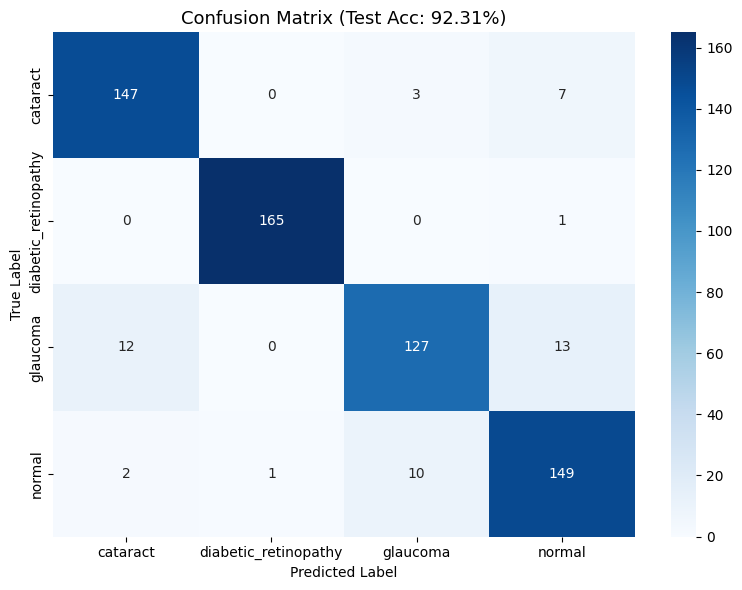


✅ All evaluation plots saved!


In [34]:
# ============================================================
# PERSON 4: Training & Evaluation
# ============================================================
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pickle

# ── Reload everything ────────────────────────────────────────
with open('/kaggle/working/loader_info.pkl', 'rb') as f:
    info = pickle.load(f)

DATA_DIR   = '/kaggle/working/eye_dataset'
BATCH_SIZE = info['batch_size']
IMG_SIZE   = info['img_size']
NUM_CLASSES = info['num_classes']
CLASSES    = info['classes']
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS     = 15

# Re-create dataloaders
norm = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(), norm
])
val_tf = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                              transforms.ToTensor(), norm])

train_loader = DataLoader(datasets.ImageFolder(f'{DATA_DIR}/train', train_tf),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(datasets.ImageFolder(f'{DATA_DIR}/val',   val_tf),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(datasets.ImageFolder(f'{DATA_DIR}/test',  val_tf),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Rebuild model
ckpt = torch.load('/kaggle/working/model_checkpoint.pth', map_location=DEVICE)

class EyeDiseaseModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        in_f = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(in_f, 256),
            nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.backbone(x)

model = EyeDiseaseModel(NUM_CLASSES).to(DEVICE)
model.load_state_dict(ckpt['model_state'])

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# ── تحميل الـ optimizer و scheduler بأمان ───────────────────
try:
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    print("✅ Optimizer & Scheduler loaded from checkpoint")
except (ValueError, KeyError):
    print("⚠️ Optimizer state mismatch - سيبدأ من أول")

# ── Training loop ────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.no_grad() if not train else torch.enable_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train: optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

print(f"🚀 Training on {DEVICE} for {EPOCHS} epochs...\n")
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()
    
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    
    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
        flag = ' ✅ saved'
    
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}{flag}")

# ── Plot Accuracy & Loss ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=100)
plt.show()

# ── Evaluate on test set ─────────────────────────────────────
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\n🎯 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'Confusion Matrix (Test Acc: {test_acc:.2%})', fontsize=13)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=100)
plt.show()

print("\n✅ All evaluation plots saved!")